# Linear Classifier Test 2 - Notebook 6.3

Testato con monai 1.5.2, torchvision 0.24, torchmetrics 1.8.2, matplotlib 3.10.8, torchinfo 1.8.0,  tqdm 4.67.2, scikit-learn 1.8.0
Classificatore lineare con input TEST2

In [2]:
import os
import numpy as np

# Import torch
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import datasets, transforms
from torchmetrics import Accuracy

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

2.8.0


Verifichiamo se il computer su cui gira il codice ha una GPU compatibile (e se pytorch è installato in modo corretto), altrimenti usiamo la CPU. Per MacOS su piattaforma sylicon usare 'mps' invece di 'cuda'  

In [3]:
# Setup device agnostic code
device = torch.device("cuda")
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Definiamo un seed per la generazione di numeri pseudo-random. I risultati dipenderanno dal seed quindi è importante mantenerlo costante in tutte le prove 

In [4]:
SEED = 42

Definiamo la cartella che contiene i dati. La cartella TEST2 contiene due folder (C,R) con all'interno 1000 immagini rappresentanti due croci leggermente diverse (un pixel di differenza) ruotate casualmente intorno al loro centro. I nomi delle cartelle rappresentano le label. Questa è la classica struttura dati che si utilizza in un task di classificazione. Il path deve essere aggiornato con quello usato sul computer dell'utente. 

In [5]:
# Load the data
# Setup path to data folder
from pathlib import Path
image_path = Path(r"C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2")   # root of data directory

Definiamo una funzione che descrive il contenuto della cartella dati 

In [6]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images \
          in '{dirpath}'.")   

walk_through_dir(image_path)  # show data structure

There are 2 directories and 0 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2'.
There are 0 directories and 1000 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2\C1'.
There are 0 directories and 1000 images           in 'C:\Users\ippop\OneDrive - University of Pisa\corso_2026\elab_bioimmagini-main\capitolo6\TEST2\C2'.


Nell'addestramento di modelli AI tipicamente utilizziamo un numero molto alto di immagini, non possiamo caricarle tutte in memoria. Quindi si usa un 'dataloader' che indicizza le immagini e le importa 'al volo' quando necessario. Definiamo la funzione che legge le immagini dal disco e le porta in memoria. In questo caso la funzione interpola le immagini a 64x64 e le trasforma in tensori che è il formato usato da Pytorch. L'interpolazione serve per ottenere immagini della stessa dimensione (qui non serve, ma in generale le immagini che usiamo potrebbero avere dimensioni diverse) ed eventualmente per ridurre l'occupazione di memoria con un sottocampionamento. Il formato tensor ottimizza le prestazioni su GPU.  

In [7]:
# Write transform for turning images into tensors
data_transform = transforms.Compose([
  # Turn the image into a torch.Tensor
  transforms.Resize(size=(64, 64)),
  transforms.ToTensor() # converts all pixel values from 0-255 to be between 0-1
])

Carichiamo i dati, o meglio creiamo una struttura che indicizza la posizione dei dati sul disco, come detto prima all_data conterrà la posizione delle immagini e non le immagini. In questo caso target_transform è nulla perchè le label sono di tipo testuale. 

In [8]:
# load data by ImageFolder
all_data = datasets.ImageFolder(root=image_path, # target folder of images 
                                  transform=data_transform, # transforms to 
                                                            # perform on data 
                                                            # (images)
                                  target_transform=None) # transforms to 
                                                         # perform on labels 
                                                         # (if necessary)

Dividiamo i dati in training set e test set in modo casuale. Il test set sarà il 10% del totale.

In [9]:
# split data set in train and test
train_dataset, test_dataset = random_split(all_data, [1800, 200])

Creiamo i dataLoader, cioè le strutture che verranno usate per l'accesso alle immagini. Usiamo un batch_size=64 per il training con shuffle per utilizzare tutti i dati. Il batch_size di default è 1, che non permette di addestrare il modello in modo efficace. Avendo 1800 immagini, avremo 28 batch "completi" con una rimanenza di 8 immagini, per cui usiamo lo shuffle per rimescolare le immagini ad ogni epoca ed utilizzare così anche queste otto immagini nel training. Se drop_last=False le otto immagini vengono inserite in un bath "incompleto" usato nel training. Per il test possiamo usare qualsiasi valore contenuto un numero esatto di volte nel test set visto che viene usato solo in inference mode. 

In [10]:
# create dataloaders batches
batch_size=64
train_dataloader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,drop_last=True)
test_dataloader = DataLoader(test_dataset,batch_size=1)

# How many batches of images are in our data loaders?
print('Numero immagini di train: ',len(train_dataloader),' Numero immagini di test: ', len(test_dataloader))
     
class_names = all_data.classes # load class names
print('Nome delle classi: ',class_names)

Numero immagini di train:  28  Numero immagini di test:  200
Nome delle classi:  ['C1', 'C2']


Usiamo il data loader per visualizzare alcune immagini.  

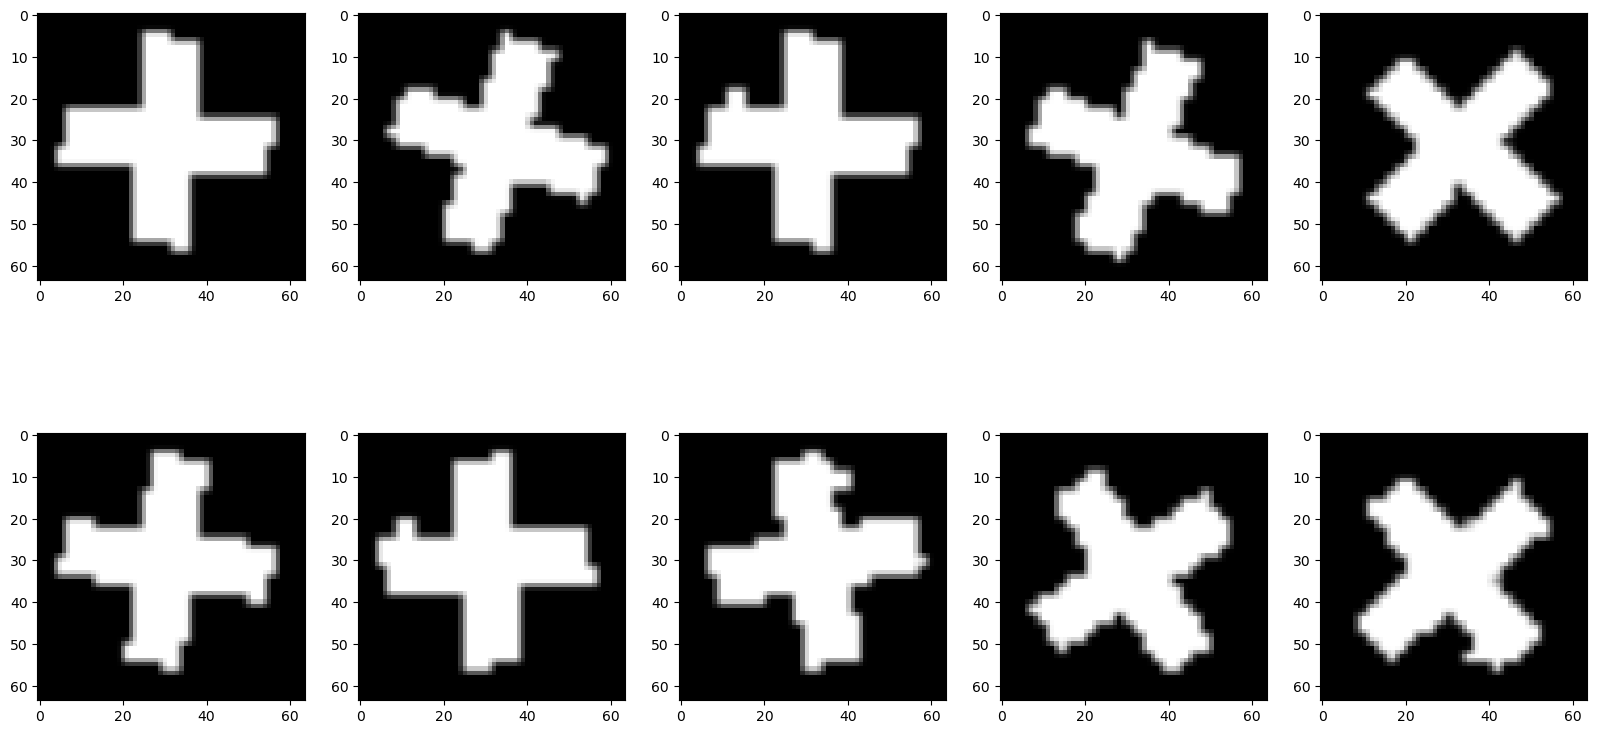

In [11]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2,5,figsize=(20,10)) # note we must use plt.subplots, not plt.subplot
for im in range(10): 
    i=im//5
    j=im-i*5
    img_label=train_dataset[im] ## extract image/label touple from dataset
    img=img_label[0] # RGB image 3x64x64
    img = np.moveaxis(img.numpy(), 0, 2) # matplotlib requires 64x64x3 format
    img = axs[i,j].imshow(img,cmap='gray')

Definiamo la dimensione dei dati di input al classificatore. Le immagini devono avere tutte la stessa dimensione

In [12]:
img=train_dataset[0]  # extract image/label touple from dataset
img_size=img[0].shape  # image size

Definiamo il classificatore lineare come modulo Pytorch. Il classificatore riceve in input una immagine di dimensione input_shape (3x64x64), la "srotola" attraverso il layer 'Flatten' ottenendo un array di dimensione 3x64x64=12288 e manda l'array in input ad un layer completamente connesso che è classificatore lineare con in uscita due classi. L'istruzione forward indica le operazioni da fare durante il passaggio di una immagine dal modulo  

In [13]:
# define linear classifier model

class linearClassifier(nn.Module):
  def __init__(self, input_shape, in_features,output_shape):
    super().__init__()
    
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=in_features,out_features=output_shape))
        
  def forward(self, x):
    x = self.classifier(x)
    return x

Definiamo il modello che useremo nella classificazione. Come si vede il modello ha circa 24500 parametri incogniti pur essendo un modello semplicissimo che usa immagini molto piccole.   

In [14]:
model = linearClassifier(input_shape = img_size[0],in_features=img_size[0]*img_size[1]*img_size[2],
                output_shape=len(class_names)).to(device)

In [15]:
from torchinfo import summary
summary(model, 
        input_size=(4, 3, img_size[1], img_size[2]), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
linearClassifier (linearClassifier)      [4, 3, 64, 64]       [4, 2]               --                   True
├─Sequential (classifier)                [4, 3, 64, 64]       [4, 2]               --                   True
│    └─Flatten (0)                       [4, 3, 64, 64]       [4, 12288]           --                   --
│    └─Linear (1)                        [4, 12288]           [4, 2]               24,578               True
Total params: 24,578
Trainable params: 24,578
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.20
Forward/backward pass size (MB): 0.00
Params size (MB): 0.10
Estimated Total Size (MB): 0.30

Definito il modello, dobbiamo definire la loss che useremo nell'addestramento (cross-entropy), l'ottimizzatore (Adam, un SDG ottimmizzato) e la metrica da usare per verificare il buon funzionamento del modello (Accuratezza). Definiamo anche il learning rate dell'ottimizzatore (il passo di campionamento del search space) che è un parametro critico per la convergenza del training 

In [15]:
accuracy_fn = Accuracy(task='multiclass', num_classes=len(class_names)).to(device)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

loss_fn=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

Definiamo la procedura di training, cioè qualla in cui vengono aggiornati i parametri. L Aprocedura prende in ingresso il modello, i dati, la loss definita prima, l'ottimizzatore, la metrica e il device che usiamo (GPU o CPU).
Come si vede la procedura itera sui minibatch che sono stati definiti alla creazione del dataloader. Legge le coppie immagine/label dal dataloader e usa il modello per predirre il valore delle label (y_pred). Calcola la loss tra le label predette e quelle "vere". La loss si "accumula" lungo i batch. Quindi si "resetta" l'ottimizzatore. Si calcola il gradiente della loss (loss.backward()) e l'ottimizzatore cambia i parametri cercando di minimizzare la loss.
Alla fine si calcolano la loss e l'accuratezza sull epoca (tutti i minibatch sono stati analizzati) 

In [16]:
# define train procedure
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device):
    train_loss, train_acc = 0, 0
    
    model.to(device)  # load the model on GPU or CPU
    
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_pred.argmax(dim=1), # logits -> pred labels
                                 y).to(device)

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    #print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    return train_loss, train_acc 

Definiamo adesso l'intera procedura di training, che itera su un certo numero di epoche chiamando la procedura definita prima e salva i valori di loss e accuratezza in una struttura.

In [17]:
def train(accuracy_fn,
          device,
          model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          ):
  
  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "val_loss": [],
             "val_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model, 
                                       data_loader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       accuracy_fn=accuracy_fn,
                                       device=device)

    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)


  # Return the results dictionary
  return results

Adesso possiamo eseguire il training del modello 

In [18]:
from tqdm.auto import tqdm
model_results = train(accuracy_fn=accuracy_fn,
                      device=device,
                      model=model,
                      train_dataloader=train_dataloader,
                      optimizer=optimizer,
                      epochs=100)

C:\Users\ippop\anaconda3\envs\jupyter\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  1%|          | 1/100 [00:01<02:05,  1.27s/it]

Epoch: 1 | train_loss: 0.8644 | train_acc: 0.4749 | 


  2%|▏         | 2/100 [00:02<01:54,  1.17s/it]

Epoch: 2 | train_loss: 0.6847 | train_acc: 0.5675 | 


  3%|▎         | 3/100 [00:03<01:51,  1.15s/it]

...

Epoch: 98 | train_loss: 0.1214 | train_acc: 0.9760 | 


 99%|█████████▉| 99/100 [01:53<00:01,  1.17s/it]

Epoch: 99 | train_loss: 0.1118 | train_acc: 0.9821 | 


100%|██████████| 100/100 [01:54<00:00,  1.15s/it]

Epoch: 100 | train_loss: 0.1090 | train_acc: 0.9827 | 


Visualizziamo le curve di addestramento

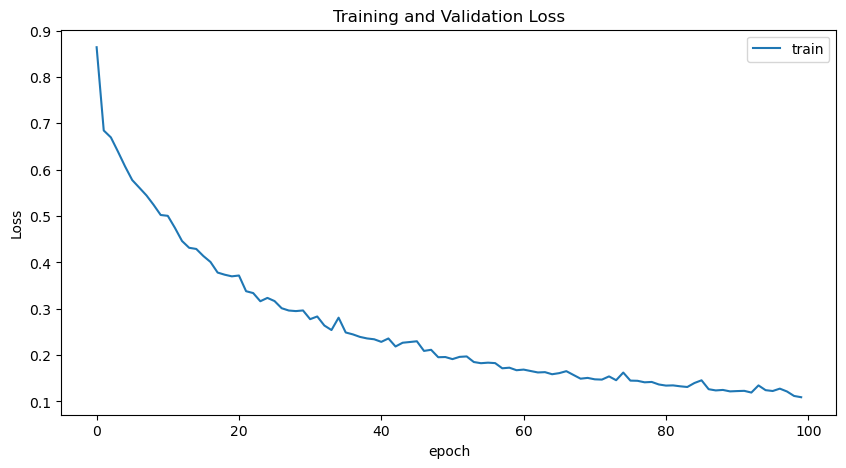

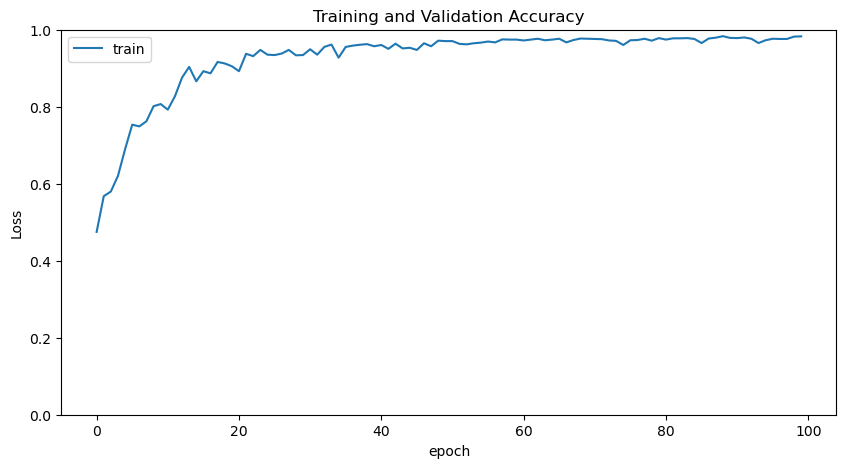

In [19]:
# plot training curves
np_train_loss = np.array([x.item() for x in model_results['train_loss']])
np_train_acc = np.array([x.item() for x in model_results['train_acc']])


plt.figure(figsize=(10,5))
plt.title("Training and Validation Loss")
plt.plot(np_train_loss,label="train")
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
plt.figure(figsize=(10,5))
plt.title("Training and Validation Accuracy")
plt.plot(np_train_acc,label="train")
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.ylim((0,1))
plt.legend()
plt.show()

Proviamo il modello addestrato sul training set. Ci mettiamo in inference_mode, cioè "congeliamo" i parametri del modello in modo che quando facciamo la predizione non vengano calcolat ii gradienti, questo ottimizza il tempo di calcolo.
Il modello nell'implementazione Pytorch restituisce degli score non normalizzati a uno per ottimizzare le prestazioni, quindi li normalizziamo a 1 con il softmax. Otteniamo il valore di accuratezza sul training set    


In [20]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

predictions = []
targets = []

with torch.inference_mode():
        for X, y in train_dataloader:
            X = X.to(device)
            y = y.to(device)
            y_logit = model(X)
            y_pred_prob = F.softmax(y_logit, dim=-1) # predicted probability
            y_pred_class = torch.argmax(y_pred_prob, dim=-1) # predicted class label
            predictions.extend(y_pred_class.tolist())
            targets.extend(y.tolist())

accuracy = accuracy_score(targets, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9810267857142857


Oltre all'accuratezza possiamo valutare altre metriche

In [21]:
from sklearn.metrics import classification_report
report = classification_report(targets, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       891
           1       0.98      0.98      0.98       901

    accuracy                           0.98      1792
   macro avg       0.98      0.98      0.98      1792
weighted avg       0.98      0.98      0.98      1792



Infine calcoliamo la confusion matrix

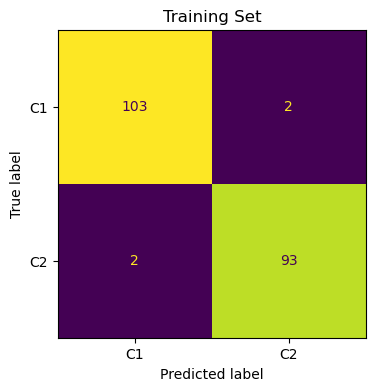

In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrix = confusion_matrix(targets, predictions)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(targets, predictions, display_labels = class_names, colorbar=False,ax=ax)
ax.set_title('Training Set');

Ripetiamo la procedura per il test set

Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       105
           1       0.98      0.98      0.98        95

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



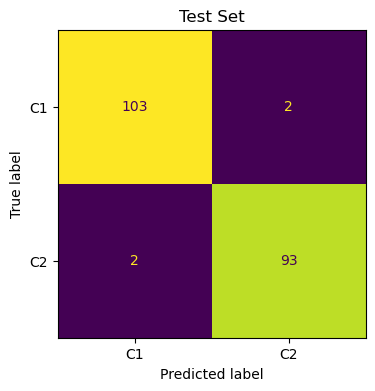

In [24]:
predictions = []
targets = []

model.eval()
with torch.inference_mode():
        for X, y in test_dataloader:
            X = X.to(device)
            y = y.to(device)
            y_logit = model(X)
            y_pred_prob = F.softmax(y_logit, dim=-1) # predicted probability
            y_pred_class = torch.argmax(y_pred_prob, dim=-1) # predicted class label
            predictions.extend(y_pred_class.tolist())
            targets.extend(y.tolist())

accuracy = accuracy_score(targets, predictions)
print("Accuracy:", accuracy)
report = classification_report(targets, predictions)
print(report)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrix = confusion_matrix(targets, predictions)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(targets, predictions, display_labels = class_names, colorbar=False,ax=ax)
ax.set_title('Test Set');

In [ ]:
Come si vede dai risultati, otteniamo prestazioni molto buone ma non perfette come nel caso dei dati di TEST1, i nquanto il problema è più complesso 